# External-trigger batching scan

This notebook compares waveform frames per block against external-trigger records per event. It uses the structured exports produced by `external_trigger_batching_scan.sh`. If no scan directory exists yet, it falls back to compatible named runs under `data/external_trigger_probe`.

In [1]:
from pathlib import Path
import json
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 120

_scan_dir_from_environment = os.environ.get("SAMPIC_BATCHING_SCAN_DIR")
SCAN_DIR_OVERRIDE = Path(_scan_dir_from_environment).expanduser() if _scan_dir_from_environment else None
EXPECTED_TRIGGER_RATE_HZ_OVERRIDE = None

def find_repo_root():
    start = Path.cwd().resolve()
    for candidate in (start, *start.parents):
        if (candidate / "scripts/tools/sampic_tests").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate the sampic_daq repository root")

REPO_ROOT = find_repo_root()
TEST_ROOT = REPO_ROOT / "scripts/tools/sampic_tests"
SCAN_ROOT = TEST_ROOT / "data/external_trigger_batching_scan"
PROBE_ROOT = TEST_ROOT / "data/external_trigger_probe"

if SCAN_DIR_OVERRIDE:
    SCAN_DIR = Path(SCAN_DIR_OVERRIDE).expanduser().resolve()
else:
    candidates = [path.parent for path in SCAN_ROOT.glob("*/scan_manifest.csv")]
    SCAN_DIR = max(candidates, key=lambda path: path.stat().st_mtime) if candidates else None

print("Repository:", REPO_ROOT)
print("Scan directory:", SCAN_DIR if SCAN_DIR else "none; using compatible probe runs")

Repository: /home/pioneer/jcarlton/projects/midas_sampic/experiments/sampic_daq
Scan directory: /home/pioneer/jcarlton/projects/midas_sampic/experiments/sampic_daq/scripts/tools/sampic_tests/data/external_trigger_batching_scan/10khz


In [2]:
def read_env_file(path):
    values = {}
    if path and path.exists():
        for line in path.read_text().splitlines():
            if line and not line.startswith("#") and "=" in line:
                key, value = line.split("=", 1)
                values[key.strip()] = value.strip()
    return values

scan_config = read_env_file(SCAN_DIR / "scan_config.env") if SCAN_DIR else {}

if SCAN_DIR:
    manifest = pd.read_csv(SCAN_DIR / "scan_manifest.csv")
    manifest = manifest[manifest["status"].isin(["complete", "reused"])]
    run_dirs = [(SCAN_DIR / value).resolve() for value in manifest["run_dir"]]
else:
    run_dirs = sorted({path.parent.resolve() for path in PROBE_ROOT.glob("*/metadata.json")})

run_dirs = list(dict.fromkeys(path for path in run_dirs if (path / "metadata.json").exists()))
if not run_dirs:
    raise FileNotFoundError("No completed batching-scan or compatible probe runs were found")

def longest_false_run(values):
    longest = current = 0
    for value in values:
        current = 0 if value else current + 1
        longest = max(longest, current)
    return longest

rows = []
for run_dir in run_dirs:
    metadata = json.loads((run_dir / "metadata.json").read_text())
    acquisition = metadata.get("acquisition", {})
    frames = acquisition.get("frames_per_block")
    trigger_batch = acquisition.get("triggers_per_event")
    if frames is None or trigger_batch is None:
        continue

    triggers = pd.read_csv(run_dir / "triggers.csv")
    hits = pd.read_csv(run_dir / "hits.csv")
    if len(triggers) < 2:
        continue

    span_s = (triggers["timestamp_ns"].iloc[-1] - triggers["timestamp_ns"].iloc[0]) * 1e-9
    timestamp_implied_trigger_rate_hz = (len(triggers) - 1) / span_s
    requested_rate_hz = acquisition.get("lecroy_readback_rate_hz")
    if requested_rate_hz is None:
        requested_rate_hz = acquisition.get("lecroy_requested_rate_hz")
    if requested_rate_hz is None and scan_config.get("expected_trigger_rate_hz"):
        requested_rate_hz = scan_config["expected_trigger_rate_hz"]
    if EXPECTED_TRIGGER_RATE_HZ_OVERRIDE is not None:
        requested_rate_hz = EXPECTED_TRIGGER_RATE_HZ_OVERRIDE
    if requested_rate_hz is None:
        requested_rate_hz = round(timestamp_implied_trigger_rate_hz / 100.0) * 100.0
    requested_rate_hz = float(requested_rate_hz)
    capture_duration_s = float(acquisition.get("excitation_wall_s", 0.0))
    if capture_duration_s <= 0.0:
        capture_duration_s = float(acquisition.get("requested_duration_s", 0.0))
    if capture_duration_s <= 0.0:
        capture_duration_s = span_s
    expected_triggers = capture_duration_s * requested_rate_hz
    association = metadata.get("association", {})
    effective_offset_ns = float(association.get("hit_time_offset_ns", -470.0))
    accepted = hits["accepted"].astype(bool)
    association_recomputed = False
    if not association.get("auto_hit_offset", False) and len(hits):
        candidates = hits.loc[hits["hit_minus_trigger_ns"].abs().le(10000.0), "hit_minus_trigger_ns"]
        if len(candidates):
            effective_offset_ns = float(candidates.median())
            residual = hits["hit_minus_trigger_ns"] - effective_offset_ns
            accepted = residual.between(
                -float(association.get("pre_window_ns", 20.0)),
                float(association.get("post_window_ns", 20.0)),
            )
            association_recomputed = True
    populated = np.zeros(len(triggers), dtype=bool)
    assigned_indices = hits.loc[accepted, "nearest_trigger_sorted_index"].dropna().astype(int)
    assigned_indices = assigned_indices[(assigned_indices >= 0) & (assigned_indices < len(triggers))]
    populated[np.unique(assigned_indices)] = True
    expected_channel_mask = (
        hits["feb"].eq(1)
        & hits["sampic"].eq(1)
        & hits["channel"].between(25, 31)
    )
    expected_channel_accepted = accepted[expected_channel_mask]
    expected_channel_hits = hits.loc[expected_channel_mask].copy()
    expected_channel_hits["accepted_for_summary"] = expected_channel_accepted.to_numpy()
    endpoint_trimmed_expected_hits = expected_channel_hits[
        expected_channel_hits["target_trigger_timestamp_ns"].le(triggers["timestamp_ns"].max())
    ]
    endpoint_trimmed_expected_hit_percent = (
        100.0 * endpoint_trimmed_expected_hits["accepted_for_summary"].sum()
        / max(1, len(endpoint_trimmed_expected_hits))
    )
    trailing_expected_hit_count = len(expected_channel_hits) - len(endpoint_trimmed_expected_hits)
    complete_wave_trigger_count = 0
    matched_expected_channel_hits = expected_channel_hits[expected_channel_hits["accepted_for_summary"]]
    if not matched_expected_channel_hits.empty:
        expected_channels_per_trigger = matched_expected_channel_hits.groupby("nearest_trigger_sorted_index")["channel"].nunique()
        complete_wave_trigger_count = int(expected_channels_per_trigger.ge(7).sum())
    fpga_steps = np.diff(triggers["fpga_id"].to_numpy(dtype=int)) % 256
    transport = metadata.get("transport", {})
    capture_wall_s = float(transport.get("capture_wall_s", 0.0))
    decoded_bytes = float(transport.get("decoded_readout_bytes", 0.0))

    rows.append({
        "run": run_dir.name,
        "requested_rate_hz": requested_rate_hz,
        "frames_per_block": int(frames),
        "triggers_per_event": int(trigger_batch),
        "received_trigger_rate_hz": len(triggers) / capture_duration_s,
        "timestamp_implied_trigger_rate_hz": timestamp_implied_trigger_rate_hz,
        "trigger_capture_percent": 100.0 * len(triggers) / expected_triggers,
        "populated_trigger_percent": 100.0 * populated.sum() / expected_triggers,
        "accepted_hit_rate_khz": accepted.sum() / capture_duration_s / 1000.0,
        "received_hit_rate_khz": len(hits) / capture_duration_s / 1000.0,
        "matched_expected_hit_percent": 100.0 * expected_channel_accepted.sum() / max(1, expected_channel_mask.sum()),
        "endpoint_trimmed_expected_hit_percent": endpoint_trimmed_expected_hit_percent,
        "trailing_expected_hit_count": trailing_expected_hit_count,
        "complete_expected_wave_trigger_percent": 100.0 * complete_wave_trigger_count / max(1, len(triggers)),
        "effective_hit_offset_ns": effective_offset_ns,
        "association_recomputed": association_recomputed,
        "longest_empty_trigger_run": longest_false_run(populated),
        "nonunit_fpga_steps": int(np.count_nonzero(fpga_steps != 1)),
        "inferred_missing_trigger_records": int(np.sum(fpga_steps[fpga_steps > 1] - 1)),
        "counter_inferred_trigger_retention_percent": 100.0 * len(triggers) / max(1, len(triggers) + int(np.sum(fpga_steps[fpga_steps > 1] - 1))),
        "decoded_readout_MBps": decoded_bytes / capture_wall_s / 1e6 if capture_wall_s else np.nan,
    })

runs = pd.DataFrame(rows).sort_values(["requested_rate_hz", "frames_per_block", "triggers_per_event", "run"])
if runs.empty:
    raise RuntimeError("Found exports, but none contain batching metadata")

print("Requested/read-back rates:", sorted(runs["requested_rate_hz"].unique()))
print(f"Loaded {len(runs)} runs")
runs

Expected trigger rate: 10000 Hz
Loaded 28 runs


,run,frames_per_block,triggers_per_event,trigger_rate_hz,trigger_capture_percent,populated_trigger_percent,accepted_hit_rate_khz,received_hit_rate_khz,association_percent,longest_empty_trigger_run,nonunit_fpga_steps,inferred_missing_trigger_records,decoded_readout_MBps
0,frames_01_triggers_001_rep_01,1,1,3819.407003,38.196050,4.357062,3.049943,3.051725,99.941619,685,1740,31209,0.404014
1,frames_01_triggers_002_rep_01,1,2,6914.779877,69.149778,4.425016,3.097511,3.099292,99.942532,652,1697,15577,0.461010
2,frames_01_triggers_004_rep_01,1,4,9997.420218,99.976177,5.213675,3.653128,3.653128,100.000000,653,0,0,0.585990
3,frames_01_triggers_008_rep_01,1,8,9997.349769,99.975473,6.028235,4.219765,4.219765,100.000000,660,0,0,0.666777
4,frames_01_triggers_016_rep_01,1,16,29996.964643,299.975570,0.000000,0.000000,13.889272,0.000000,50640,0,0,0.720844
5,frames_01_triggers_032_rep_01,1,32,29997.414758,299.980073,0.000000,0.000000,17.797095,0.000000,50624,0,0,0.904440
6,frames_01_triggers_064_rep_01,1,64,29995.836562,299.964291,0.000000,0.000000,16.766335,0.000000,50624,0,0,0.859423
7,frames_01_triggers_127_rep_01,1,127,29993.870557,299.944640,0.000000,0.000000,16.909790,0.000000,50546,0,0,0.860957
8,frames_02_triggers_001_rep_01,2,1,12430.119627,124.307135,0.000000,0.000000,20.142151,0.000000,20930,1963,29573,0.845034
9,frames_02_triggers_002_rep_01,2,2,18786.946948,187.875404,0.000000,0.000000,16.514615,0.000000,31658,1514,18886,0.758711


In [3]:
group_columns = ["requested_rate_hz", "frames_per_block", "triggers_per_event"]
metric_columns = [column for column in runs.select_dtypes(include="number").columns if column not in group_columns]
summary = runs.groupby(group_columns)[metric_columns].mean().reset_index()
# A run length is an integer property of one capture. Averaging two
# repetitions produces meaningless half-trigger values, so display the
# worst observed run length at each grid point instead.
summary["longest_empty_trigger_run"] = (
    runs.groupby(group_columns)["longest_empty_trigger_run"].max().to_numpy()
)

display_columns = [
    "requested_rate_hz", "frames_per_block", "triggers_per_event",
    "received_trigger_rate_hz", "timestamp_implied_trigger_rate_hz",
    "trigger_capture_percent", "populated_trigger_percent",
    "accepted_hit_rate_khz",
    "matched_expected_hit_percent", "complete_expected_wave_trigger_percent",
    "endpoint_trimmed_expected_hit_percent", "trailing_expected_hit_count",
    "longest_empty_trigger_run", "decoded_readout_MBps",
]
summary[display_columns].round(3)

,frames_per_block,triggers_per_event,trigger_rate_hz,trigger_capture_percent,populated_trigger_percent,accepted_hit_rate_khz,association_percent,longest_empty_trigger_run,decoded_readout_MBps
0,1.0,1.0,3819.407,38.196,4.357,3.050,99.942,685.0,0.404
1,1.0,2.0,6914.780,69.150,4.425,3.098,99.943,652.0,0.461
2,1.0,4.0,9997.420,99.976,5.214,3.653,100.000,653.0,0.586
3,1.0,8.0,9997.350,99.975,6.028,4.220,100.000,660.0,0.667
4,1.0,16.0,29996.965,299.976,0.000,0.000,0.000,50640.0,0.721
5,1.0,32.0,29997.415,299.980,0.000,0.000,0.000,50624.0,0.904
6,1.0,64.0,29995.837,299.964,0.000,0.000,0.000,50624.0,0.859
7,1.0,127.0,29993.871,299.945,0.000,0.000,0.000,50546.0,0.861
8,2.0,1.0,12430.120,124.307,0.000,0.000,0.000,20930.0,0.845
9,2.0,2.0,18786.947,187.875,0.000,0.000,0.000,31658.0,0.759


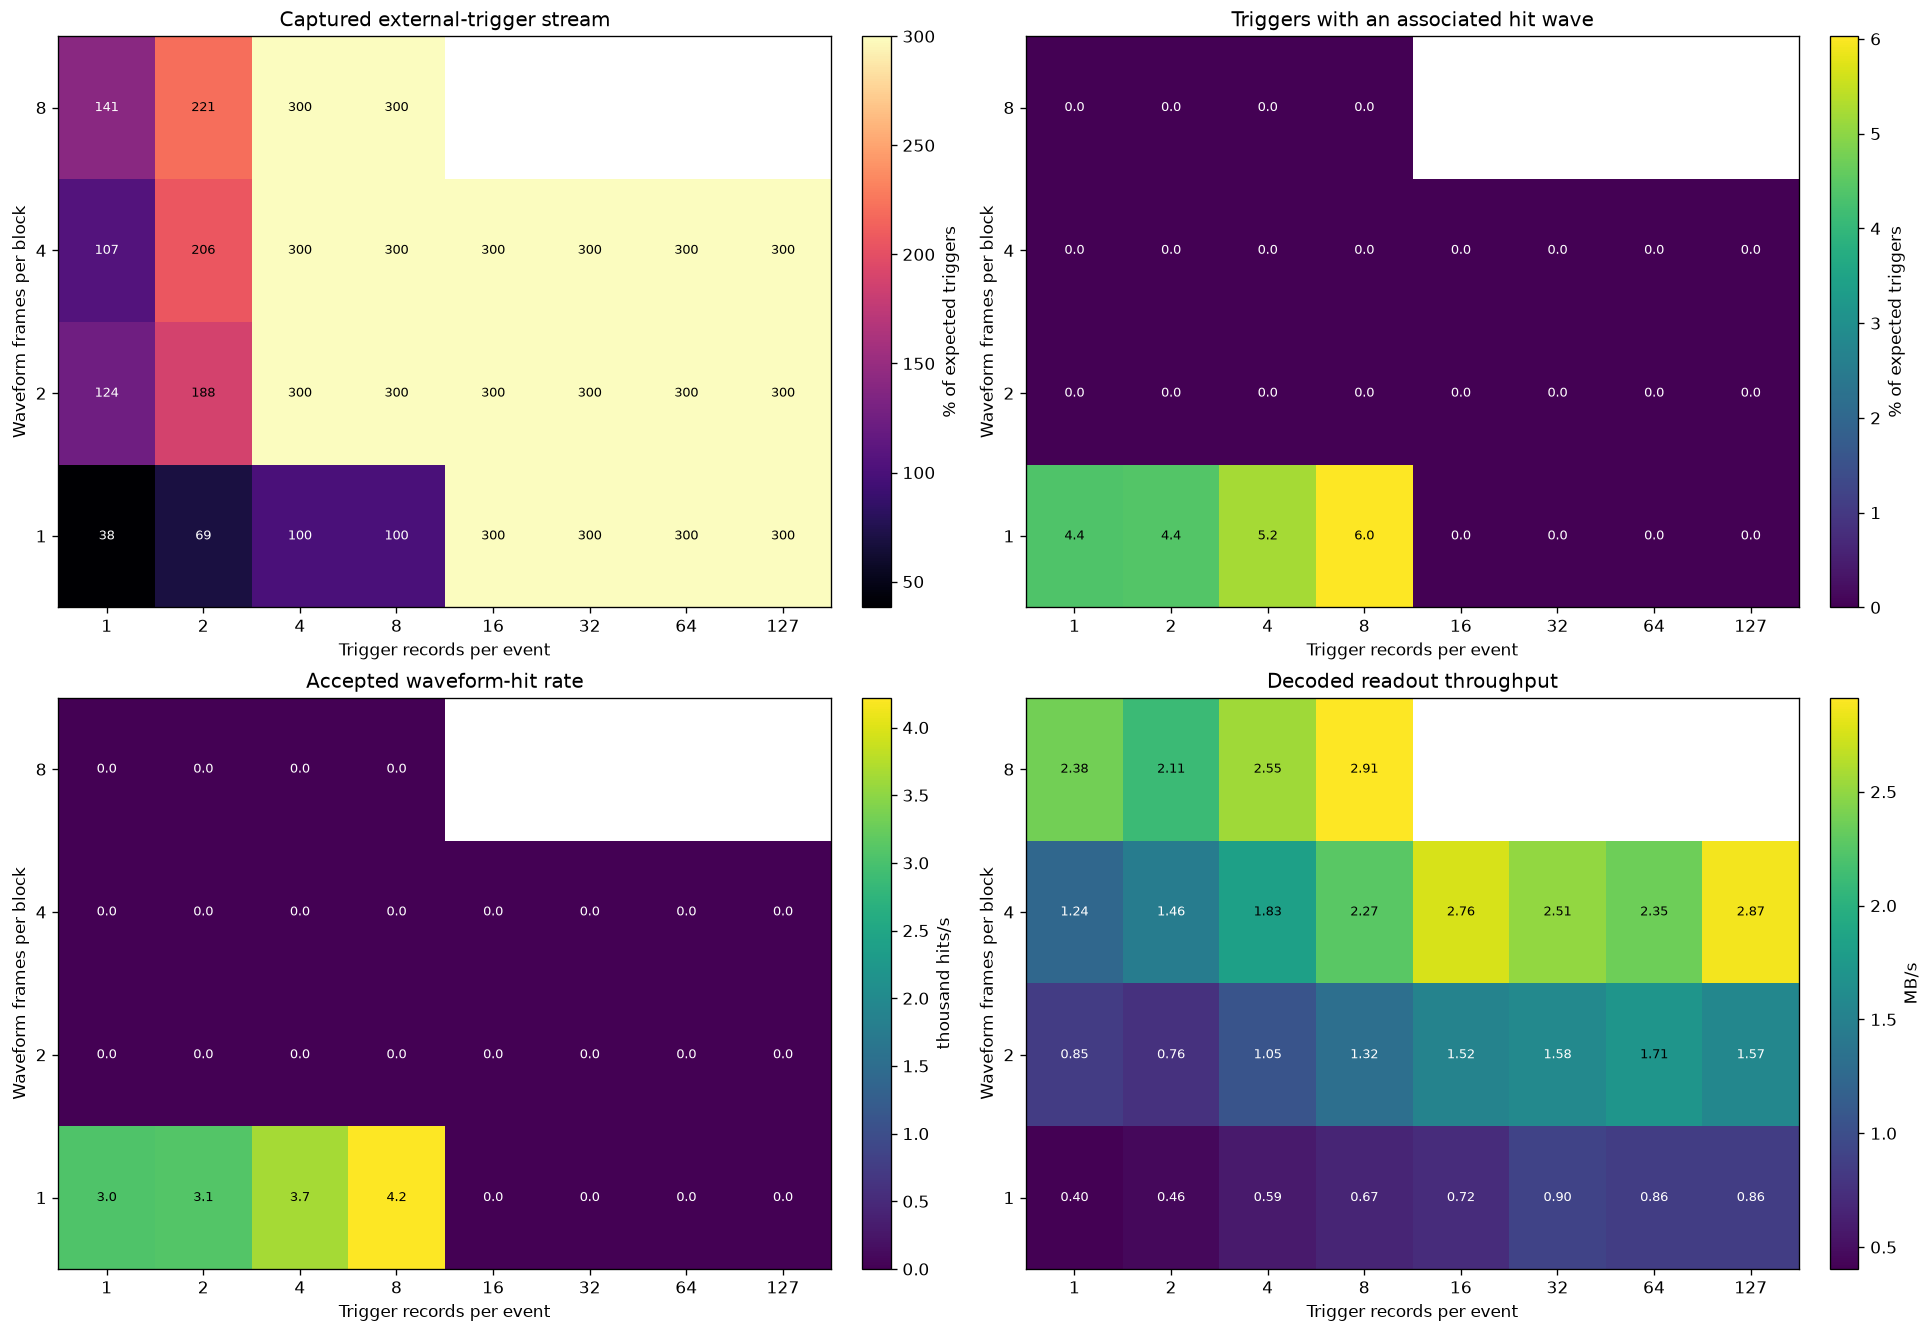

In [4]:
def draw_heatmap(ax, rate_summary, metric, title, colorbar_label, fmt=".1f", cmap="viridis", vmin=None, vmax=None):
    table = rate_summary.pivot(index="frames_per_block", columns="triggers_per_event", values=metric)
    frame_values = table.index.to_numpy(dtype=int)
    trigger_values = table.columns.to_numpy(dtype=int)
    image = ax.imshow(table.to_numpy(), origin="lower", aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_xticks(np.arange(len(trigger_values)), labels=trigger_values)
    ax.set_yticks(np.arange(len(frame_values)), labels=frame_values)
    ax.set_xlabel("Trigger records per event")
    ax.set_ylabel("Waveform frames per block")
    ax.set_title(title)

    values = table.to_numpy()
    finite = values[np.isfinite(values)]
    color_min = vmin if vmin is not None else (finite.min() if finite.size else 0)
    color_max = vmax if vmax is not None else (finite.max() if finite.size else 0)
    midpoint = (color_min + color_max) / 2
    for row in range(values.shape[0]):
        for column in range(values.shape[1]):
            value = values[row, column]
            if np.isfinite(value):
                color = "white" if value < midpoint else "black"
                ax.text(column, row, format(value, fmt), ha="center", va="center", color=color, fontsize=8)

    above_mtu = np.flatnonzero(frame_values > 8)
    if above_mtu.size:
        boundary = above_mtu[0] - 0.5
        ax.axhline(boundary, color="red", linestyle="--", linewidth=1.5)
        ax.text(
            len(trigger_values) - 0.5, boundary + 0.08,
            "above MTU-1500 single-datagram estimate",
            color="red", ha="right", va="bottom", fontsize=8,
        )
    colorbar = ax.figure.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    colorbar.set_label(colorbar_label)

def draw_rate_dashboard(requested_rate_hz, rate_summary, *, endpoint_trimmed=False):
    fig, axes = plt.subplots(4, 2, figsize=(16, 19), constrained_layout=True)
    if endpoint_trimmed:
        title = (
            f"Trailing-endpoint-trimmed comparison: {requested_rate_hz:g} Hz\n"
            "Expected-channel targets after the final received trigger are excluded"
        )
        hit_metric = "endpoint_trimmed_expected_hit_percent"
        hit_title = "Expected-channel hit match after trailing trim"
        hit_colorbar = "% of retained hits on FEB 1 / SAMPIC 1 / channels 25-31"
    else:
        title = f"Requested/read-back generator rate: {requested_rate_hz:g} Hz"
        hit_metric = "matched_expected_hit_percent"
        hit_title = "Expected-channel hits with a matching trigger"
        hit_colorbar = "% of hits on FEB 1 / SAMPIC 1 / channels 25-31"
    fig.suptitle(title, fontsize=15)
    draw_heatmap(axes[0, 0], rate_summary, "trigger_capture_percent", "Captured external-trigger stream", "% of expected triggers", fmt=".3f", cmap="magma")
    draw_heatmap(axes[0, 1], rate_summary, "populated_trigger_percent", "Triggers with an associated hit wave", "% of expected triggers", fmt=".3f")
    draw_heatmap(axes[1, 0], rate_summary, "accepted_hit_rate_khz", "Accepted waveform-hit rate", "thousand hits/s during capture", fmt=".3f")
    draw_heatmap(axes[1, 1], rate_summary, "decoded_readout_MBps", "Decoded readout throughput", "MB/s", fmt=".3f")
    draw_heatmap(axes[2, 0], rate_summary, hit_metric, hit_title, hit_colorbar, fmt=".3f", cmap="magma", vmin=0, vmax=100)
    draw_heatmap(axes[2, 1], rate_summary, "complete_expected_wave_trigger_percent", "External triggers with the complete expected 7-channel wave", "% of decoded trigger records", fmt=".3f", cmap="magma", vmin=0, vmax=100)
    draw_heatmap(axes[3, 0], rate_summary, "longest_empty_trigger_run", "Maximum longest empty-trigger run across repetitions", "consecutive decoded trigger records", fmt=".0f", cmap="plasma")
    draw_heatmap(axes[3, 1], rate_summary, "counter_inferred_trigger_retention_percent", "Internal FPGA-ID gap retention", "received / (received + ID-inferred internal gaps), %", fmt=".3f", cmap="cividis", vmin=0, vmax=100)
    plt.show()

for requested_rate_hz, rate_summary in summary.groupby("requested_rate_hz"):
    draw_rate_dashboard(requested_rate_hz, rate_summary)

for requested_rate_hz, rate_summary in summary.groupby("requested_rate_hz"):
    draw_rate_dashboard(requested_rate_hz, rate_summary, endpoint_trimmed=True)

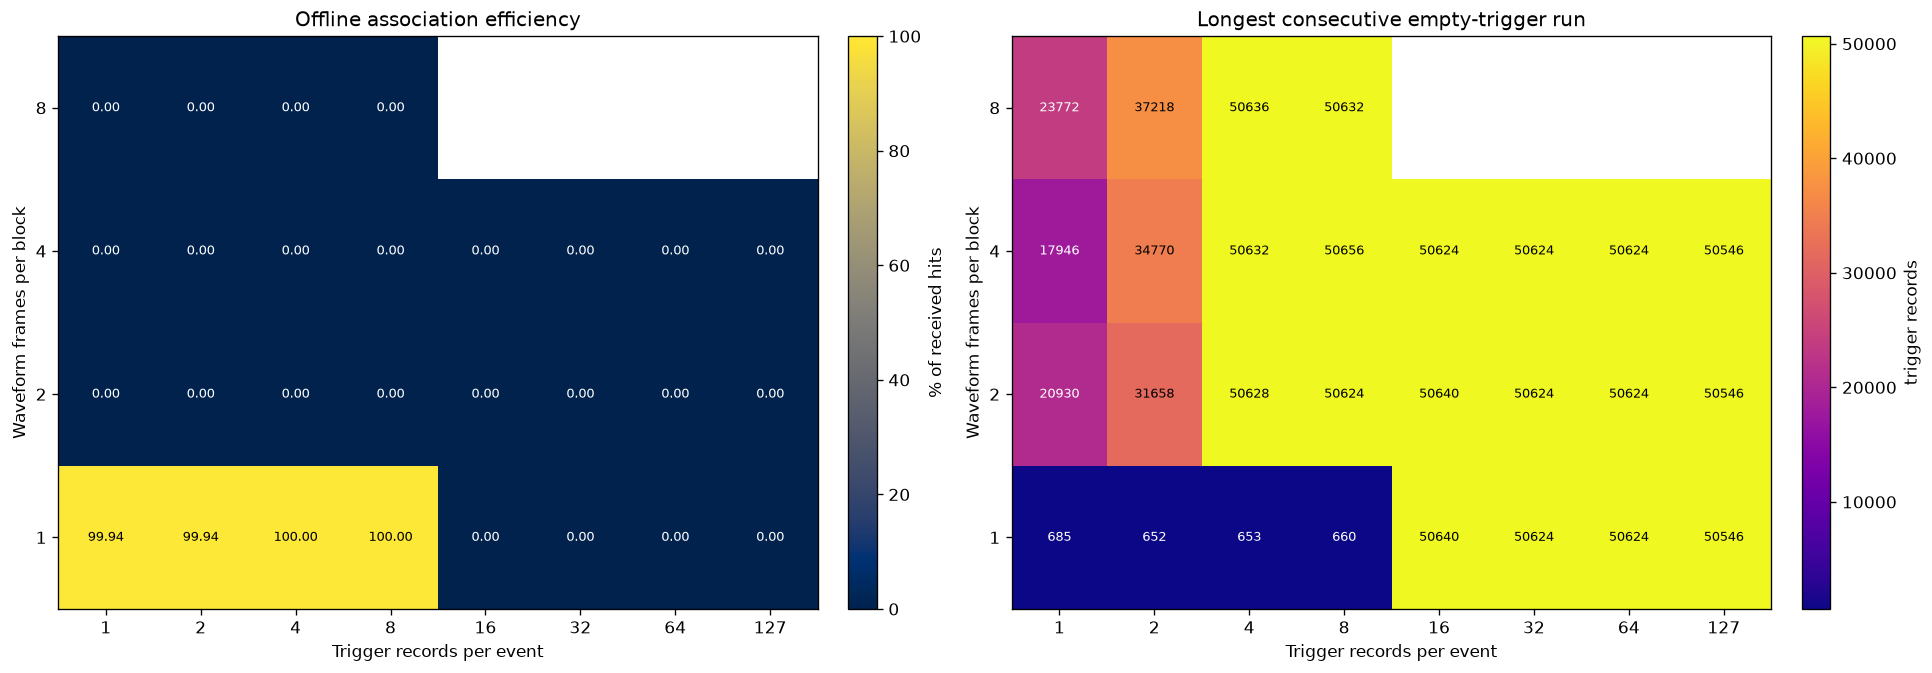

In [5]:
if len(runs) > len(summary):
    variability = runs.groupby(["requested_rate_hz", "frames_per_block", "triggers_per_event"])[
        ["trigger_capture_percent", "populated_trigger_percent", "accepted_hit_rate_khz"]
    ].agg(["mean", "std", "count"])
    display(variability.round(3))